In [2]:
import pandas as pd

df = pd.read_csv("location_metrics_corrected.csv")  # 본인 경로에 맞게 수정

# 전체 평균 생존기간 (episode 개수 가중평균 - 위치별 평균의 단순평균이 아니라
# 실제 전체 episode 기준으로 정확하게 계산)
df['episode수'] = df['교체횟수'] + 1
overall_avg_survival = df['관측분기수'].sum() / df['episode수'].sum()
print(f"전체 평균 생존기간(episode 가중평균): {overall_avg_survival:.2f}분기")

# 조건: 관측분기수 15+ (신뢰가능) & 교체횟수 2회 & 
#       최장생존분기수 < 전체평균 (이러면 3개 episode 전부 평균 미만이 보장됨)
reliable = df[df['관측분기수'] >= 15]
target = reliable[
    (reliable['교체횟수'] == 2) &
    (reliable['최장생존분기수'] < overall_avg_survival)
].copy()

print(f"\n조건 만족 위치 수: {len(target):,} / 신뢰가능 전체 {len(reliable):,}")
print(target[['관측분기수','평균생존분기수','최장생존분기수','교체율']].describe())

target = target.sort_values('평균생존분기수')
print(target[['위치ID','관측분기수','평균생존분기수','최장생존분기수','교체율']].head(20).to_string(index=False))

전체 평균 생존기간(episode 가중평균): 16.13분기

조건 만족 위치 수: 14,646 / 신뢰가능 전체 311,428
              관측분기수       평균생존분기수       최장생존분기수           교체율
count  14646.000000  14646.000000  14646.000000  14646.000000
mean      24.049297      8.016432     12.342073      0.093801
std        6.583780      2.194593      2.727028      0.025586
min       15.000000      5.000000      5.000000      0.051282
25%       19.000000      6.333333     10.000000      0.071429
50%       23.000000      7.666667     13.000000      0.090909
75%       29.000000      9.666667     15.000000      0.111111
max       40.000000     13.333333     16.000000      0.142857
                     위치ID  관측분기수  평균생존분기수  최장생존분기수      교체율
  1111017000100980001_1_1     15      5.0       11 0.142857
  1111016300102310025_1_1     15      5.0       10 0.142857
  1111016300100760000_3_2     15      5.0       10 0.142857
  1111016300100450001_1_1     15      5.0        7 0.142857
  1111015600101090002_1_1     15      5.0        8 0.142857
  11200115

In [3]:
target.to_csv("u    nderperform_2turnover.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: underperform_2turnover.csv")


저장 완료: underperform_2turnover.csv


생존구간
5-6      3484
7-8      5023
9-10     3367
11-12    1963
13-14     809
15-16       0
Name: count, dtype: int64


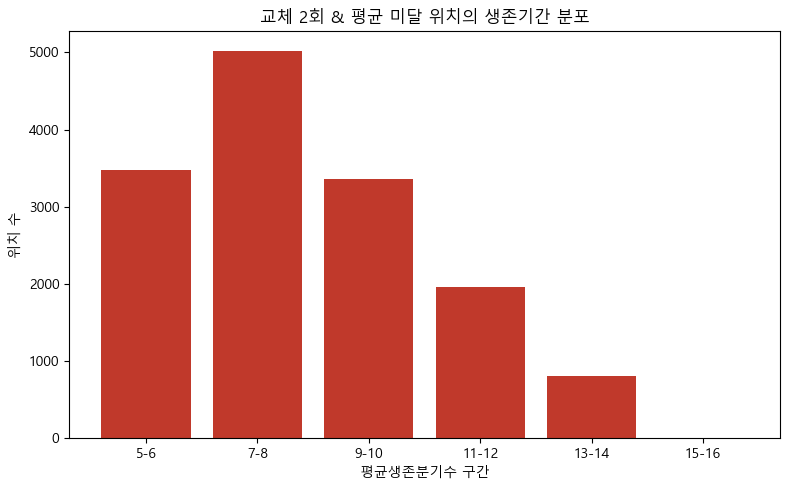

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

bins = [0, 6, 8, 10, 12, 14, 16]
labels = ['5-6', '7-8', '9-10', '11-12', '13-14', '15-16']
target['생존구간'] = pd.cut(target['평균생존분기수'], bins=bins, labels=labels, include_lowest=True)
dist = target['생존구간'].value_counts().reindex(labels)
print(dist)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dist.index.astype(str), dist.values, color='#c0392b')
ax.set_xlabel('평균생존분기수 구간')
ax.set_ylabel('위치 수')
ax.set_title('교체 2회 & 평균 미달 위치의 생존기간 분포')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
ep = pd.read_parquet("tenancy_episode_corrected.parquet")

print(ep['생존분기수_보정'].describe())
# 이제 위치 단위가 아니라 episode(개별 입점) 단위 분포

count    665001.000000
mean         16.130595
std          12.902737
min           1.000000
25%           5.000000
50%          12.000000
75%          26.000000
max          40.000000
Name: 생존분기수_보정, dtype: float64


In [6]:
ep.head(2)

,위치ID,episode_id,상가업소번호,시작분기,종료분기,생존분기수,생존여부,생존분기수_보정
0,1111010100100010000_1_1,1,MA010120220800078856,201512,201809,11,폐업,11
1,1111010100100010000_1_1,2,MA010120220806718407,201812,202512,29,생존중,29


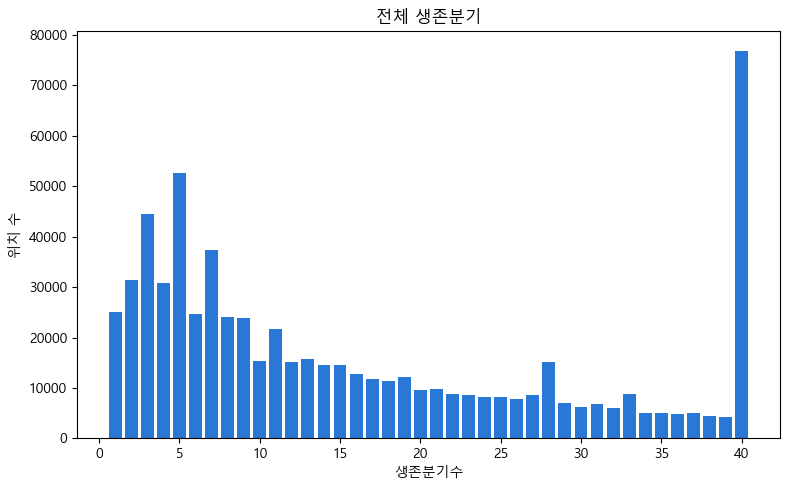

In [7]:
    fig, ax = plt.subplots(figsize=(8, 5))
    counts = ep['생존분기수_보정'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#2a78d6')
    ax.set_xlabel('생존분기수')
    ax.set_ylabel('위치 수')
    ax.set_title('전체 생존분기')
    plt.tight_layout()
    plt.show()


폐업한 episode 수: 367104
count    367104.000000
mean         10.851102
std           8.899708
min           1.000000
25%           4.000000
50%           8.000000
75%          15.000000
max          39.000000
Name: 생존분기수_보정, dtype: float64


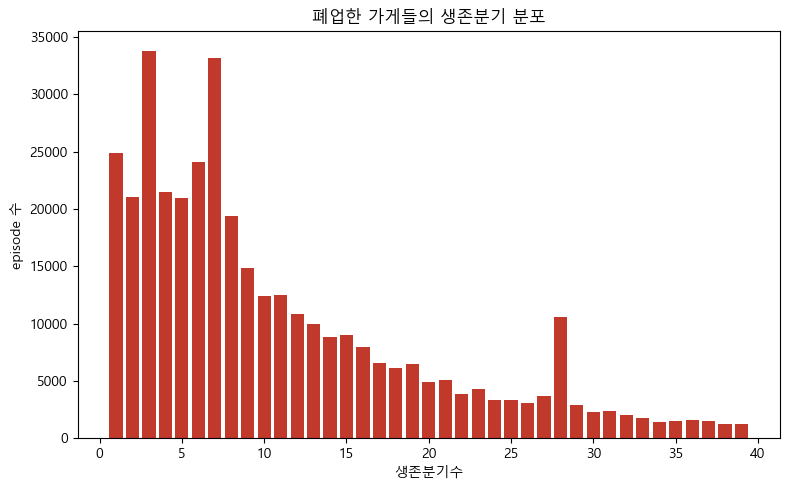

In [8]:
closed = ep[ep['생존여부'] == '폐업']       # 진짜 망한 것들만
alive = ep[ep['생존여부'] == '생존중']       # 아직 살아있는 것들 (별도 취급)

print("폐업한 episode 수:", len(closed))
print(closed['생존분기수_보정'].describe())

# 다시 그래프
fig, ax = plt.subplots(figsize=(8,5))
counts = closed['생존분기수_보정'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#c0392b')
ax.set_xlabel('생존분기수')
ax.set_ylabel('episode 수')
ax.set_title('폐업한 가게들의 생존분기 분포')
plt.tight_layout()
plt.show()

In [ ]:
# 생존분기 25~30 구간 실제 수치 확인 (28분기에서 튀는 스파이크 확인용)
counts = closed['생존분기수_보정'].value_counts().sort_index()
print(counts.loc[25:30])

# 25~30분기 각각에 대해, 그 episode들이 언제 시작했는지 확인 -> 특정 시작분기에 쏠려있는지 체크
for q in range(25, 31):
    spike = ep[(ep['생존여부']=='폐업') & (ep['생존분기수_보정']==q)]
    print(f"\n[생존분기수_보정 == {q}] (총 {len(spike):,}건)")
    print(spike['시작분기'].value_counts().head(5))

In [9]:
# 초기 급감 구간이 어디서 완만해지는지(변곡점) 찾기
counts = closed['생존분기수_보정'].value_counts().sort_index()
diffs = counts.diff()  # 분기가 늘 때마다 개수가 얼마나 줄어드는지
print(diffs.head(15))
# 감소폭이 갑자기 작아지는 지점 = "급격한 초기 폐업 구간이 끝나는 지점"

생존분기수_보정
1         NaN
2     -3868.0
3     12762.0
4    -12347.0
5      -529.0
6      3176.0
7      9061.0
8    -13739.0
9     -4562.0
10    -2474.0
11      155.0
12    -1655.0
13     -901.0
14    -1180.0
15      177.0
Name: count, dtype: float64


In [ ]:
# 28분기 근처 episode들이 유독 보정(bad_periods 병합)의 영향을 받았는지 확인
around_28 = ep[(ep['생존여부']=='폐업') & (ep['생존분기수_보정'].between(26,30))]
print(len(around_28))
# tenancy_episode.parquet(보정 전 원본)이랑 비교해서, 이 그룹이 원래는 짧았다가 늘어난 건지 확인
ep_before = pd.read_parquet("tenancy_episode.parquet")
merged_check = around_28.merge(
    ep_before[['위치ID','상가업소번호','생존분기수']],
    on=['위치ID','상가업소번호'], how='left', suffixes=('_후','_전')
)
# around_28(ep, 보정 후 파일)에도 '생존분기수' 원본 컬럼이 이미 있어서 merge 시 이름이
# 겹침 -> suffixes=('_후','_전')에 의해 '생존분기수_후'(보정후 파일의 원본값),
# '생존분기수_전'(비교 대상 원본 파일의 값)으로 자동 변경됨. 비교하려던 '생존분기수'는
# 더 이상 존재하지 않아 KeyError 발생 -> '생존분기수_전'으로 수정.
merged_check['보정차이'] = merged_check['생존분기수_보정'] -     merged_check['생존분기수_전']
print(merged_check[['생존분기수_전','생존분기수_보정','보정차이']].describe())

22551
            생존분기수_전      생존분기수_보정          보정차이
count  22582.000000  22582.000000  22582.000000
mean      27.784474     27.897706      0.113232
std        1.617873      1.109833      1.181944
min        1.000000     26.000000      0.000000
25%       27.000000     27.000000      0.000000
50%       28.000000     28.000000      0.000000
75%       28.000000     28.000000      0.000000
max       30.000000     30.000000     29.000000


In [11]:
spike28 = ep[(ep['생존여부']=='폐업') & (ep['생존분기수_보정']==28)]
print(spike28['시작분기'].value_counts().head(5))

시작분기
201512    9357
201712     169
201806     154
201803     142
201812     120
Name: count, dtype: int64
